# 08 — Scenario Analysis

Raising the service level buys fewer stockouts with more inventory. The cost curve is U-shaped and its minimum is the economically reasonable service level — **under the stated assumptions**, which the data cannot supply.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
warnings.filterwarnings('ignore')

from src.config import load_config
from src.data.loader import load_panel
cfg = load_config()
panel = load_panel(cfg)
print(f'panel: {len(panel):,} rows, {panel.series_id.nunique()} series, {panel.date.nunique()} days')

panel: 1,003,600 rows, 600 series, 1969 days


In [2]:
import pandas as pd
from src.run import load_results
r = load_results(cfg)
sc = pd.DataFrame(r['scenarios']['scenario_table'])
sc.round(4)

,service_level,z,mean_safety_stock,total_safety_stock,achieved_fill_rate,achieved_cycle_sl,units_short,avg_inventory_units,holding_cost_cu,stockout_cost_cu,ordering_cost_cu,total_cost_cu,is_cost_minimum
0,0.90,1.2816,9.0412,5424.6958,0.9724,0.9746,682.6316,15913.8724,1057.4723,483.9062,1738.0,3279.3785,False
1,0.95,1.6449,11.6042,6962.5217,0.9787,0.9825,526.6775,17430.6796,1155.8570,336.0275,1740.0,3231.8845,True
2,0.99,2.3263,16.4120,9847.2273,0.9860,0.9904,346.4815,20272.1849,1342.4639,206.0097,1746.0,3294.4736,False


## The analytical cross-check

Newsvendor theory says the optimal service level is the critical ratio `Cu / (Cu + Co)`. Computing both the closed form and the simulated optimum makes each a check on the other.

In [3]:
r['scenarios']['newsvendor'], r['scenarios']['cost_optimal_service_level']

({'critical_ratio_mean': 0.963060686015831,
  'critical_ratio_median': 0.9630606860158312,
  'cu_mean_cu': 2.2612252029776574,
  'co_mean_cu': 0.08673192559366356},
 0.95)

## Sensitivity: the recommendation moves with the assumptions

In [4]:
pd.DataFrame(r['scenarios']['sensitivity']).round(4)

,stockout_penalty_multiplier,cost_optimal_service_level,total_cost_cu,achieved_fill_rate,avg_inventory_units
0,1.0,0.90,3037.4254,0.9724,15913.8724
1,2.0,0.95,3231.8845,0.9787,17430.6796
2,4.0,0.99,3500.4833,0.9860,20272.1849


## The cost curve

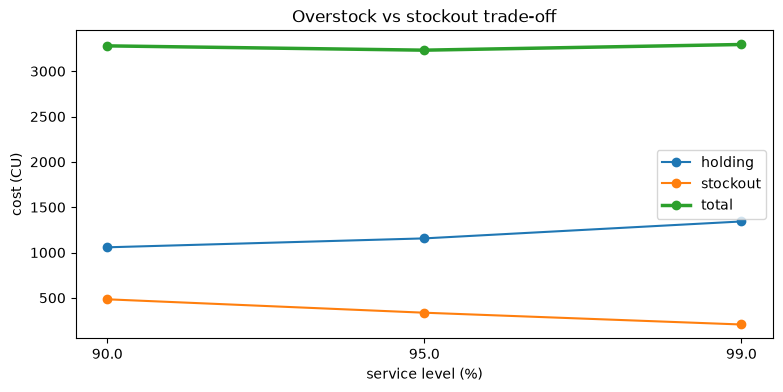

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9,4))
x = (sc.service_level*100).astype(str)
ax.plot(x, sc.holding_cost_cu, 'o-', label='holding')
ax.plot(x, sc.stockout_cost_cu, 'o-', label='stockout')
ax.plot(x, sc.total_cost_cu, 'o-', lw=2.5, label='total')
ax.set_xlabel('service level (%)'); ax.set_ylabel('cost (CU)')
ax.legend(); ax.set_title('Overstock vs stockout trade-off')
plt.show()

## Example decision

The forecast turned into an order.

In [6]:
from src.inference.forecaster import DemandForecaster, format_recommendation
from src.data.loader import test_fold
f = DemandForecaster.load(cfg)
seg = pd.read_parquet(cfg.resolve('data','processed_dir')/'segments.parquet')
sid = str(seg.sort_values('total_demand', ascending=False).index[0])
print(format_recommendation(f.recommend(panel, sid, origin=test_fold(cfg).origin)))

DEMAND FORECAST & REORDER RECOMMENDATION — FOODS_3_555_TX_1
  forecast origin       : 2016-05-22
  horizon               : 28 days
  total forecast demand : 818.4 units
  lead time + review    : 7 + 7 = 14 days of exposure
  expected LT demand    : 412.3 units
  safety stock          : 27.7 units (at 95% service level)
  REORDER POINT         : 441 units
  stockout risk         : 4.4% (normal approximation)

  note: inventory figures use the assumed economics in configs/config.yaml;
        they are not measured business results.
